In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Raw/cleaned_day2.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,y,previously_contacted
0,58,Management,Married,Tertiary,No,2143.0,Yes,No,Unknown,5,May,261,1.0,-1,0,No,0
1,44,Technician,Single,Secondary,No,29.0,Yes,No,Unknown,5,May,151,1.0,-1,0,No,0
2,33,Entrepreneur,Married,Secondary,No,2.0,Yes,Yes,Unknown,5,May,76,1.0,-1,0,No,0
3,47,Blue-collar,Married,Secondary,No,1506.0,Yes,No,Unknown,5,May,92,1.0,-1,0,No,0
4,33,Blue-collar,Single,Secondary,No,1.0,No,No,Unknown,5,May,198,1.0,-1,0,No,0


# UNIVARIATE ANALYSIS


### Numerical Analysis

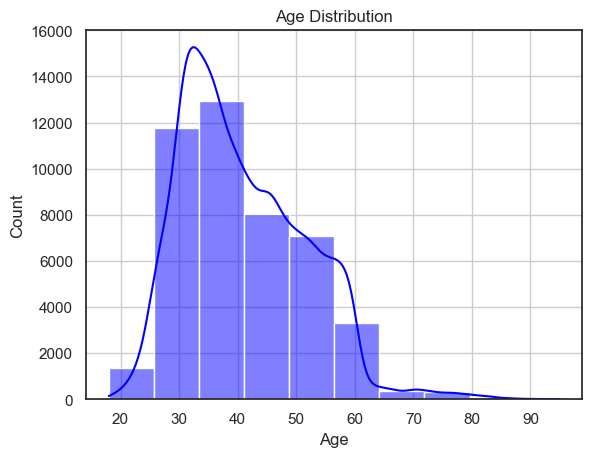

In [163]:
#Distribution of age

sns.set_style("white")
sns.histplot(data=df,x="age",bins=10,color="blue",kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.grid()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/Age-Distribution.png",dpi=300,bbox_inches='tight')
plt.show()

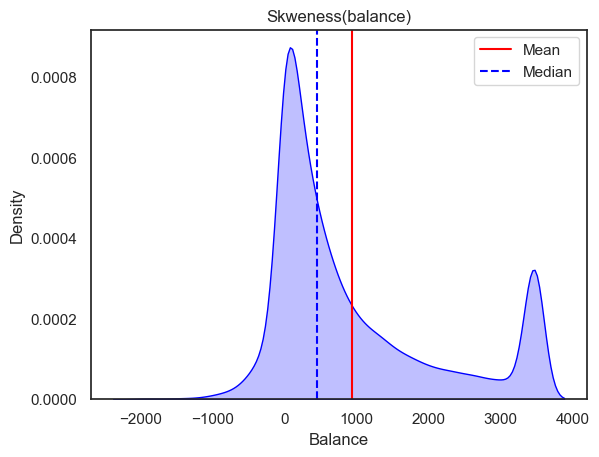

In [164]:
#skewness of balance

sns.set_style("white")
sns.kdeplot(data=df,x="balance",fill=True,color='blue')
plt.axvline(df["balance"].mean(),color='red',label="Mean")
plt.axvline(df["balance"].median(),color='blue',linestyle='--',label="Median")
plt.xlabel("Balance")
plt.title("Skweness(balance)")
plt.legend()
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/balanceSkweness.png",dpi=300,bbox_inches='tight')

### Categorical Analysis

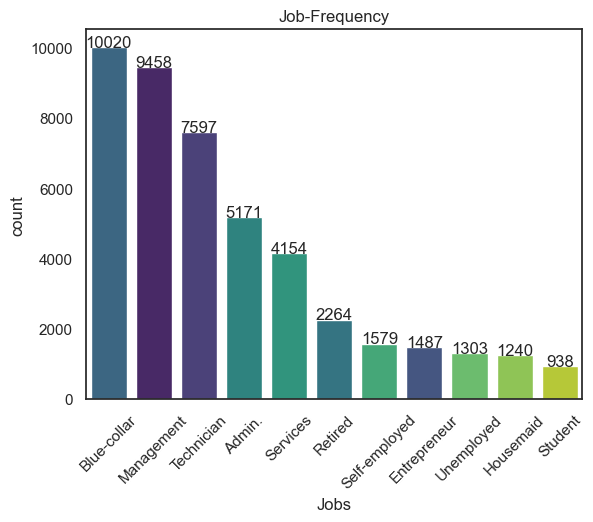

In [165]:
#Frequency of job

ax = sns.countplot(data=df,x="job",hue="job",order=df["job"].value_counts().index,palette="viridis")
plt.xticks(rotation=45)
plt.title("Job-Frequency")
plt.xlabel("Jobs")
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height(),int(p.get_height()),ha="center")
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/FrequencyOfJob.png",dpi=300,bbox_inches='tight')

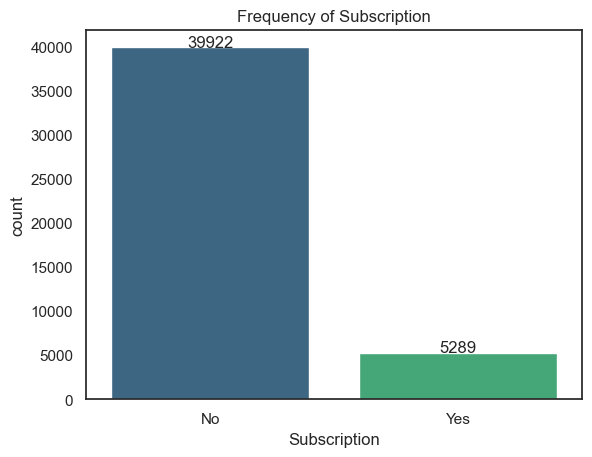

In [166]:
#Frequency of Subscription

ax = sns.countplot(data=df,x="y",hue="y",palette="viridis")
plt.xlabel("Subscription")
plt.title("Frequency of Subscription")
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,p.get_height(),int(p.get_height()),ha="center") 
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/FrequencyOfSubscription.png",dpi=300,bbox_inches='tight')

### Univariate Analysis: Findings & Insights

**1.Age Distribution (Numerical)**
**Findings:**
- The age distribution is right-skewed.
- The majority of clients fall between **30 and 40 years**.

**Insights:**
- The bank’s core audience consists of working-age professionals.
- Clients aged **above 60** are under-represented, indicating a missed opportunity, as seniors are typically high-value depositors.

---

**2.Balance Skewness (Numerical)**
**Findings:**
- The balance distribution shows extreme right skewness.
- The **Mean (Red)** lies far to the right of the **Median (Blue)**.

**Insights:**
- A small number of wealthy **VIP customers** significantly inflate the average balance.
- The **median balance** better represents a typical customer’s wealth, while the average can be misleading for business decisions.

---

**3.Job Frequency (Categorical)**
**Findings:**
- **Blue-collar**, **Management**, and **Technician** roles dominate the dataset.
- These three job categories account for **more than 50%** of all clients.

**Insights:**
- Marketing volume is primarily driven by these job segments.
- Campaign messaging should emphasize:
  - **Stability and security** for Blue-collar clients
  - **Growth and investment opportunities** for Management professionals

---

**4.Subscription Frequency (Categorical)**
**Findings:**
- The target variable is highly imbalanced.
- Approximately **88%** of clients did not subscribe, while only **12%** subscribed.

**Insights:**
- The current marketing campaign demonstrates a low conversion rate.
- Any predictive model built on this data should handle class imbalance carefully and prioritize metrics such as **F1-score, Precision, or Recall** over Accuracy.


# BIVARIATE ANALYSIS


### Numeric-Numeric

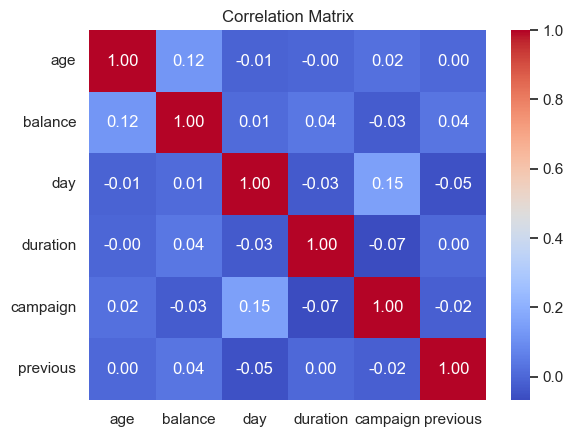

In [167]:
#Correlation Heatmap

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'previous']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/CorrelationMatrix.png",dpi=300,bbox_inches='tight')
plt.show()

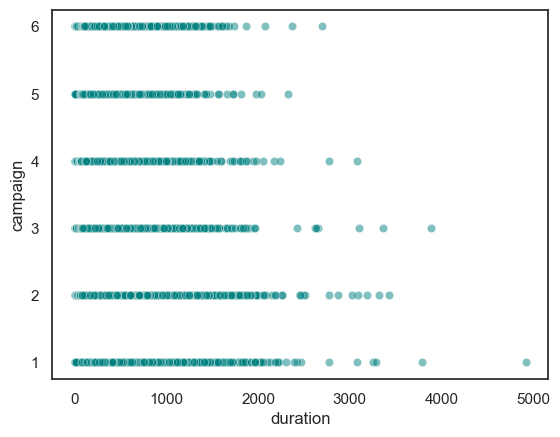

In [168]:
#Duration vs. Campaign

sns.scatterplot(data=df,x='duration',y='campaign',alpha=0.5,color='teal')
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/DurationVScampaign.png",dpi=300,bbox_inches='tight')

### Numeric–categorical

C:\Users\Dell\AppData\Local\Temp\ipykernel_22388\836362286.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='y', y='duration', palette='viridis')


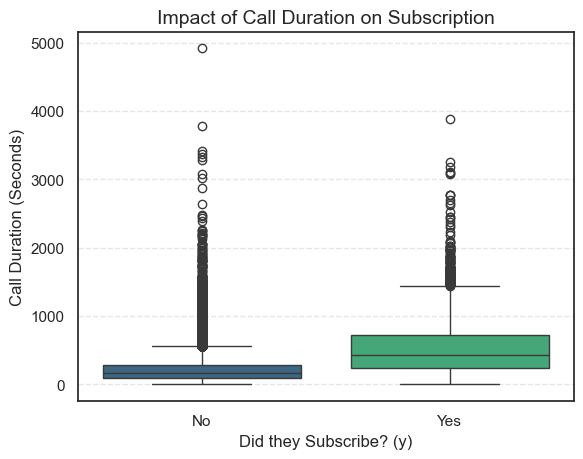

In [179]:
#Duration Vs Subscription

sns.boxplot(data=df, x='y', y='duration', palette='viridis')

plt.title('Impact of Call Duration on Subscription', fontsize=14)
plt.xlabel('Did they Subscribe? (y)')
plt.ylabel('Call Duration (Seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/DurationVSsubscription.png",dpi=300,bbox_inches='tight')          

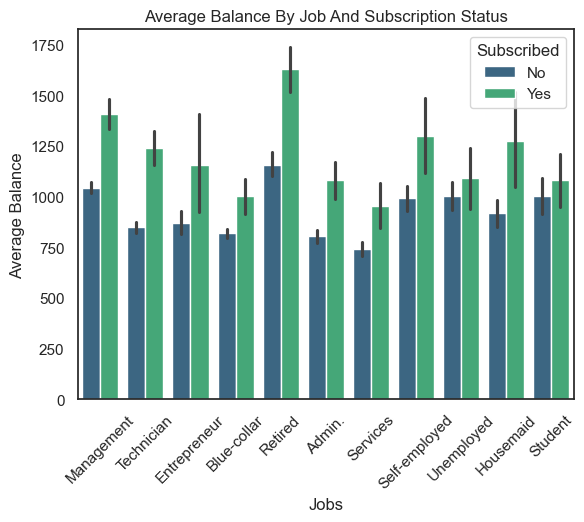

In [170]:
#Average Balance By Job And Subscription Status

sns.barplot(data=df,x="job", y="balance", hue="y", palette="viridis")
plt.title("Average Balance By Job And Subscription Status")
plt.xlabel("Jobs")
plt.ylabel("Average Balance")
plt.legend(title='Subscribed')
plt.xticks(rotation=45)
plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/AvgBalanceByJob&subscription.png",dpi=300,bbox_inches='tight')

### Bivariate Analysis: Findings & Insights

**1.Correlation Matrix (Heatmap)**
**Findings:**
- Most variables exhibit weak or no correlation.
- The heatmap is dominated by neutral colors, indicating low linear relationships.

**Insights:**
- Features are largely independent, reducing concerns about multicollinearity.
- No single variable (e.g., Age) strongly predicts another (e.g., Balance).
- Predictive power will likely come from **feature combinations**, not individual variables.
  
---

**2.Duration vs. Campaign (Scatterplot)**
**Findings:**
- The plot shows an **L-shaped distribution**.
- Longer call durations occur only when the number of contacts is low (1–3).
- When contact attempts exceed 10, call duration drops close to zero.

**Insights:**
- Repeated calling leads to disengagement rather than meaningful conversations.
- The optimal strategy is to **stop calling after the 3rd attempt**, as additional attempts waste resources and reduce effectiveness.

---

**3.Duration vs. Subscription (Boxplot)**
**Findings:**
- The median call duration for subscribers (**"Yes"**) is approximately **3× longer** than for non-subscribers.
- Subscriber calls typically last **7–9 minutes**, while non-subscriber calls average around **2–3 minutes**.

**Insights:**
- Call duration is the **strongest indicator of customer interest** observed in the analysis.
- Short calls usually indicate immediate rejection.
- Once a conversation exceeds **5 minutes**, the probability of a successful subscription increases dramatically, making duration a critical real-time signal for sales effectiveness.


---

**4.Average Balance by Job & Subscription (Barplot)**
**Findings:**
- For **Retired** and **Management** roles, the average balance of subscribers is noticeably higher than that of non-subscribers.
- For other job categories (e.g., Blue-collar), the difference is minimal.

**Insights:**
- Balance is a strong driver of subscription behavior for **Retirees and Management professionals**.
- High-balance clients in these segments represent **high-probability targets**.
- For other job roles, factors beyond balance are more influential and should guide targeting strategies.


# SEGMENT ANALYSIS

C:\Users\Dell\AppData\Local\Temp\ipykernel_22388\1418130826.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stats= df.groupby('age_group')['y'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()


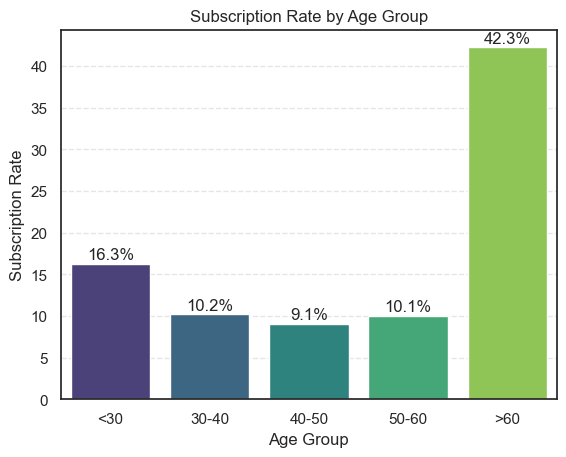

In [171]:
#Subscription Rate By Age Groups

bins = [0, 30, 40, 50, 60, 100]
labels = ["<30", "30-40", '40-50', '50-60', ">60"]
df["age_group"] = pd.cut(df['age'], bins=bins, labels=labels)
age_stats= df.groupby('age_group')['y'].apply(lambda x: (x=='Yes').mean() * 100).reset_index()
age_stats.rename(columns={'y': 'subscription_rate'}, inplace=True)

ax = sns.barplot(data=age_stats,y="subscription_rate",x="age_group",hue="age_group",palette="viridis")
plt.title("Subscription Rate by Age Group")
plt.ylabel("Subscription Rate")
plt.xlabel('Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height()+0.5,f"{p.get_height():.1f}%",ha="center")

plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/SubscriptionRatebyAge-group.png",dpi=300,bbox_inches='tight')

C:\Users\Dell\AppData\Local\Temp\ipykernel_22388\744168009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=marital_stats,x="marital", y="y",palette="viridis")


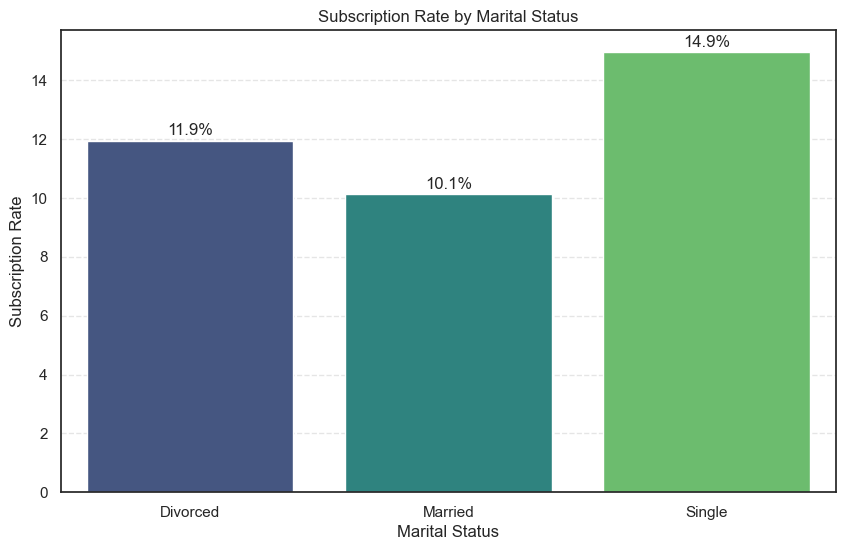

In [172]:
#Subscription rate By Marital Status

marital_stats = df.groupby("marital")["y"].apply(lambda x: (x=='Yes').mean()*100).reset_index()
plt.figure(figsize=(10, 6))

ax = sns.barplot(data=marital_stats,x="marital", y="y",palette="viridis")
plt.title("Subscription Rate by Marital Status")
plt.ylabel("Subscription Rate")
plt.xlabel("Marital Status") 
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2,p.get_height()+0.2,f"{p.get_height():.1f}%",ha="center")

plt.savefig("C:/Users/Dell/OneDrive/Desktop/EDA PROJECT/Reports/Fiqures/SubscriptionRateByMaritalStatus.png",dpi=300,bbox_inches='tight')

## Segment-Level Analysis:Fidnings & Insights

**1.Age Group**
**Findings:**
- The subscription rate follows a **U-shaped pattern**.
- Clients aged **below 30** and **above 60** show the highest likelihood of subscribing.
- **Middle-aged clients (30–50)** exhibit the lowest subscription rates.

**Insights:**
- Conversion is strongest at the **edges of the age spectrum**.
- **Retirees (>60)** represent the most valuable untapped segment and should be a primary focus for future campaigns.

---

**2.Marital Status**
**Findings:**
- **Single clients** have a higher subscription rate compared to **married clients**.

**Insights:**
- Family responsibilities may reduce the willingness of married clients to commit funds to long-term deposits.
- Single individuals generally have greater financial flexibility, making them more receptive to investment-oriented products.
